In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
data = pd.read_excel("Taylor_Swift_Genius_Data.xlsx",header=0)
data['Album'] = data['Album'].astype(str)
data['Song Name'] = data['Song Name'].astype(str)


In [3]:
def convertir_duracion(tiempo):
    minuto = tiempo//60
    segundos = tiempo%60
    segundos = round(segundos,1)
    return str(minuto)+"m "+str(segundos)+ "s"

In [4]:
data.head()

,Track Number,Album,Taylor's Version,Song Name,Duration (s),From The Vault,Lyrics
0,10,Taylor Swift,No,Mary's Song (Oh My My My),213,NaN,She said I was seven and you were nine I looke...
1,14,Taylor Swift,No,A Perfectly Good Heart,220,NaN,Why would you wanna break A perfectly good hea...
2,1,Taylor Swift,No,Tim McGraw,232,NaN,He said the way my blue eyes shined Put those ...
3,3,Taylor Swift,No,Teardrops On My Guitar,203,NaN,Drew looks at me I fake a smile so he won't se...
4,5,Taylor Swift,No,Cold as You,239,NaN,You have a way of coming easily to me And when...


### Análisis General

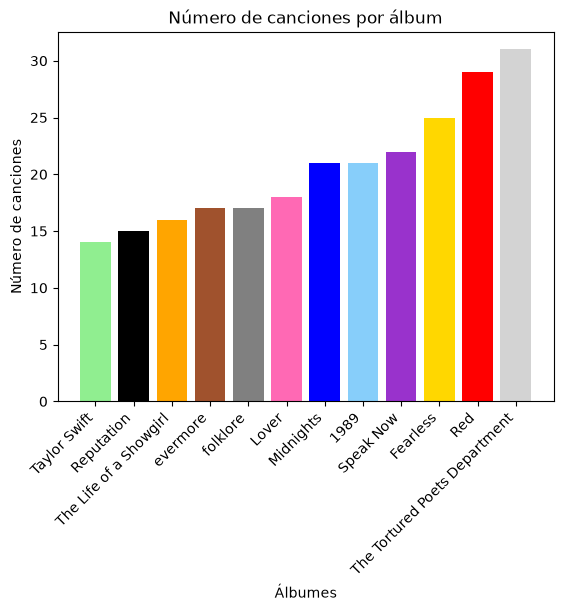

In [55]:
y = data.groupby('Album')['Track Number'].count().sort_values()
x = y.index

colors = {
    'Taylor Swift': 'lightgreen',
    'Fearless': 'gold',
    'Speak Now': 'darkorchid',
    'Red': 'red',
    '1989': 'lightskyblue',
    'Reputation': 'black',
    'Lover': 'hotpink',
    'folklore': 'grey',
    'evermore': 'sienna',
    'Midnights': 'blue',
    'The Tortured Poets Department': 'lightgrey',
    'The Life of a Showgirl': 'orange'
}

plt.bar(x, y, color=[colors[album] for album in x])
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("Número de canciones")
plt.xlabel("Álbumes")
plt.title("Número de canciones por álbum")
plt.show()

### Duration Analysis

In [5]:
sorted_column = data.sort_values(['Duration (s)'], ascending = False)
sorted_column.head()
sorted_column.tail()

,Track Number,Album,Taylor's Version,Song Name,Duration (s),From The Vault,Lyrics
129,17,Lover,No,It's Nice to Have a Friend,150,NaN,"Ooh Ooh School bell rings, walk me home Sidew..."
243,9,The Life of a Showgirl,No,Wood,150,NaN,"Daisy's bare naked, I was distraught He loves..."
198,18,Midnights,No,Glitch,148,NaN,We were supposed to be just friends You don't...
110,19,1989,Yes,Now That We Don't Talk,146,Yes,You went to a party I heard from everybody You...
228,25,The Tortured Poets Department,No,I Look in People's Windows,131,NaN,I had died the tiniest death I spied the catc...


In [6]:
max_tiempo = data["Duration (s)"].max()
min_tiempo = data["Duration (s)"].min()

In [7]:
print("Canción de mayor duración:",data.loc[data['Duration (s)'].idxmax(), 'Song Name'])
print(convertir_duracion(max_tiempo))
print("Canción de menor duración:",data.loc[data['Duration (s)'].idxmin(), 'Song Name'])
print(convertir_duracion(min_tiempo))
print("Tiempo promedio de canciones")
print(convertir_duracion(data["Duration (s)"].mean()))

Canción de mayor duración: All Too Well (10 Minute Version)
10m 13s
Canción de menor duración: I Look in People's Windows
2m 11s
Tiempo promedio de canciones
3.0m 55.5s


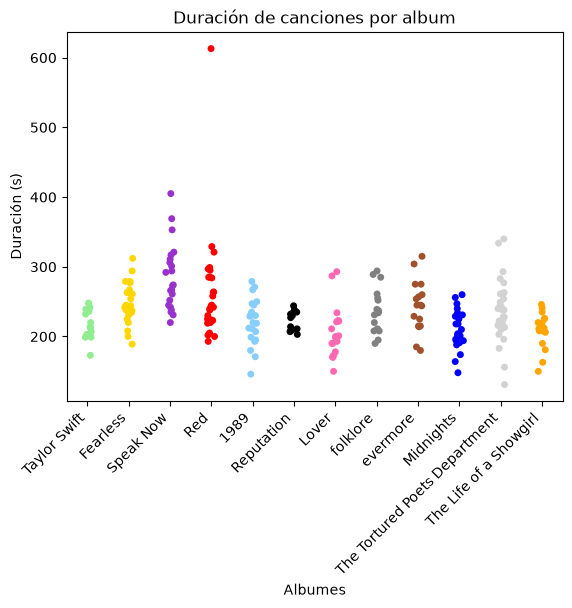

In [8]:
sns.stripplot(data=data,x='Album',y='Duration (s)',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("Duración (s)")
plt.xlabel("Albumes")
plt.title("Duración de canciones por album")
plt.show()

Album
1989                             4868
Fearless                         6422
Lover                            3705
Midnights                        4824
Red                              7826
Reputation                       3338
Speak Now                        6273
Taylor Swift                     3027
The Life of a Showgirl           3340
The Tortured Poets Department    7341
evermore                         4137
folklore                         4019
Name: Duration (s), dtype: int64


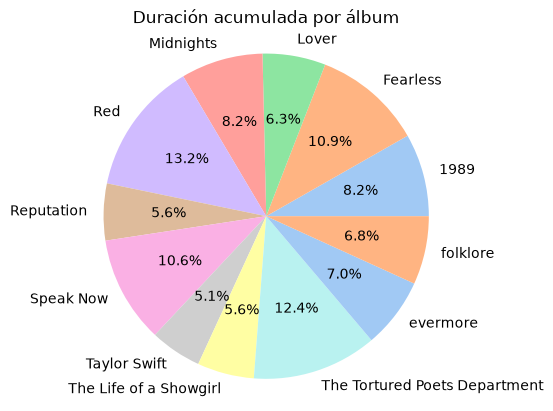

In [9]:
album_duration = data.groupby("Album")["Duration (s)"].sum()
print(album_duration)
plt.pie(album_duration,labels=album_duration.index,colors= sns.color_palette('pastel'),autopct='%1.1f%%',radius=1.1)
plt.title("Duración acumulada por álbum")
plt.show()

In [10]:
album_mayor = album_duration.idxmax()
album_menor = album_duration.idxmin()
album_songs = data.groupby("Album").size()
print("Album de mayor duración:",album_mayor)
print(convertir_duracion(album_duration[album_mayor]))
print("Número de canciones: ",album_songs[album_mayor])
print("Album de menor duración: ",album_menor)
print(convertir_duracion(album_duration[album_menor]))
print("Número de canciones: ",album_songs[album_menor])

Album de mayor duración: Red
130m 26s
Número de canciones:  30
Album de menor duración:  Taylor Swift
50m 27s
Número de canciones:  14


Mostrar los tracks 5

In [11]:
# Dos opciones para mostrar
print(data[data["Track Number"]==5][["Song Name","Album"]])
print(data.loc[data["Track Number"] == 5, ["Song Name", "Album"]])

                      Song Name                          Album
4                   Cold as You                   Taylor Swift
18                  White Horse                       Fearless
44                    Dear John                      Speak Now
66                 All Too Well                            Red
96   All You Had To Do Was Stay                           1989
118                    Delicate                     Reputation
146                  The Archer                          Lover
153           my tears ricochet                       folklore
174                 tolerate it                       evermore
188     You're On Your Own, Kid                      Midnights
208               So Long, Lond  The Tortured Poets Department
239             Eldest Daughter         The Life of a Showgirl
                      Song Name                          Album
4                   Cold as You                   Taylor Swift
18                  White Horse                       F

In [12]:
print(data.loc[data["Track Number"] == 5, ["Song Name", "Album"]].to_string(index=False)) # Sin mostrar el índice

                 Song Name                         Album
               Cold as You                  Taylor Swift
               White Horse                      Fearless
                 Dear John                     Speak Now
              All Too Well                           Red
All You Had To Do Was Stay                          1989
                  Delicate                    Reputation
                The Archer                         Lover
         my tears ricochet                      folklore
               tolerate it                      evermore
   You're On Your Own, Kid                     Midnights
             So Long, Lond The Tortured Poets Department
           Eldest Daughter        The Life of a Showgirl


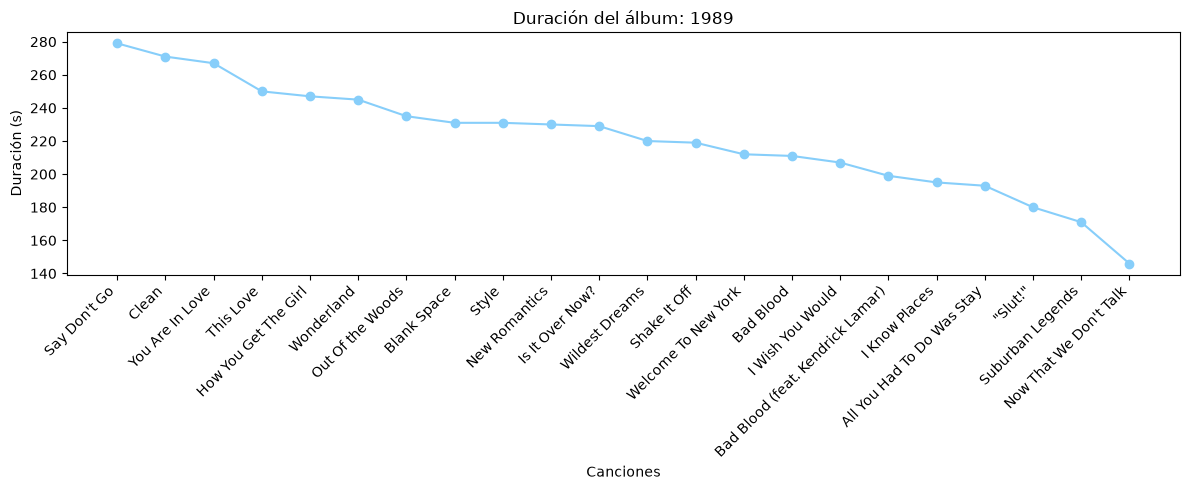

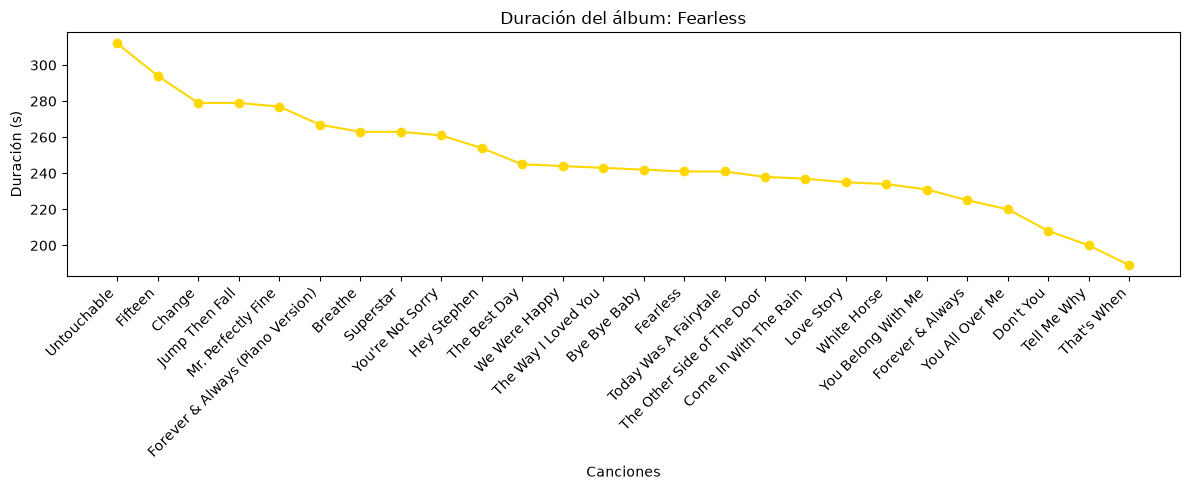

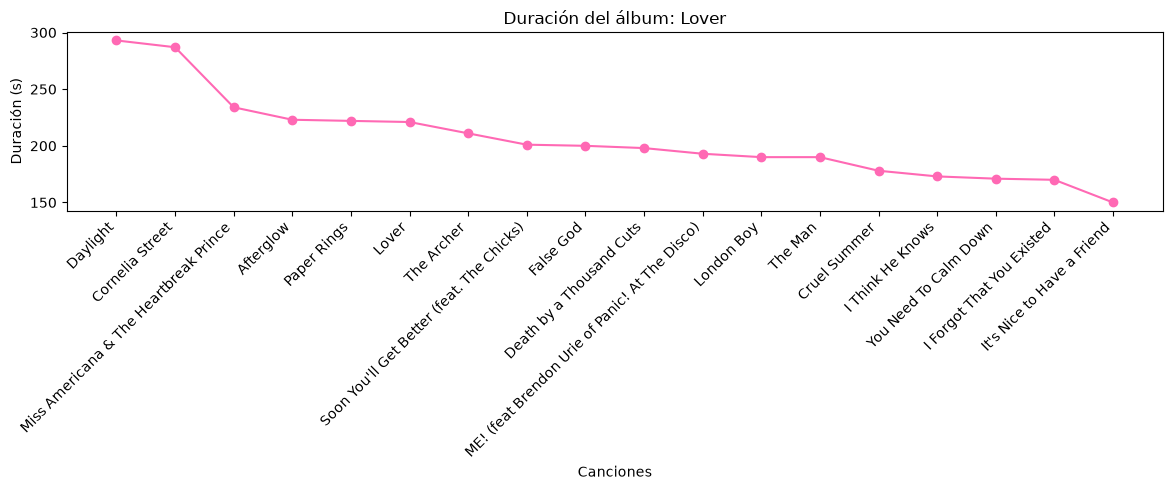

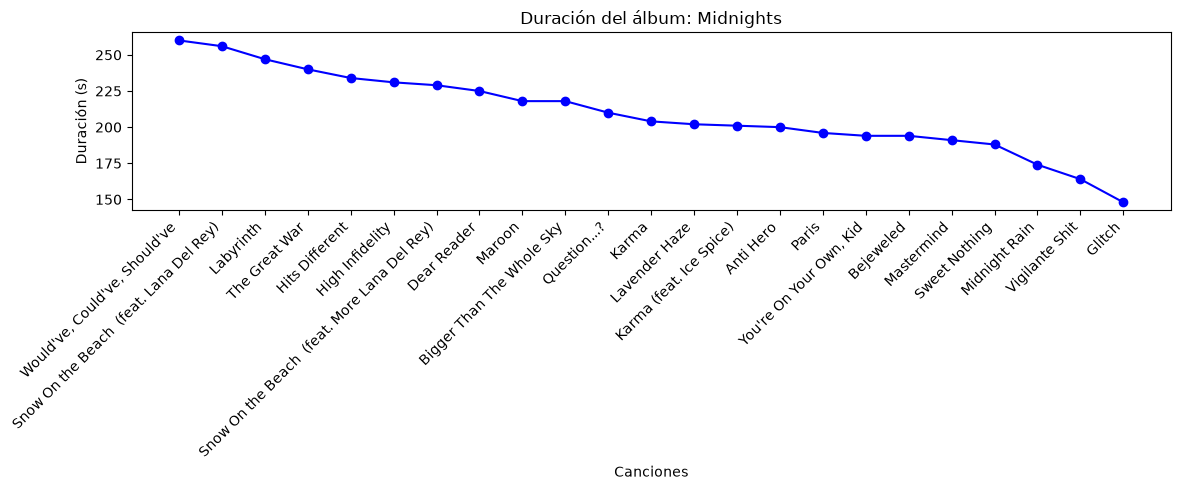

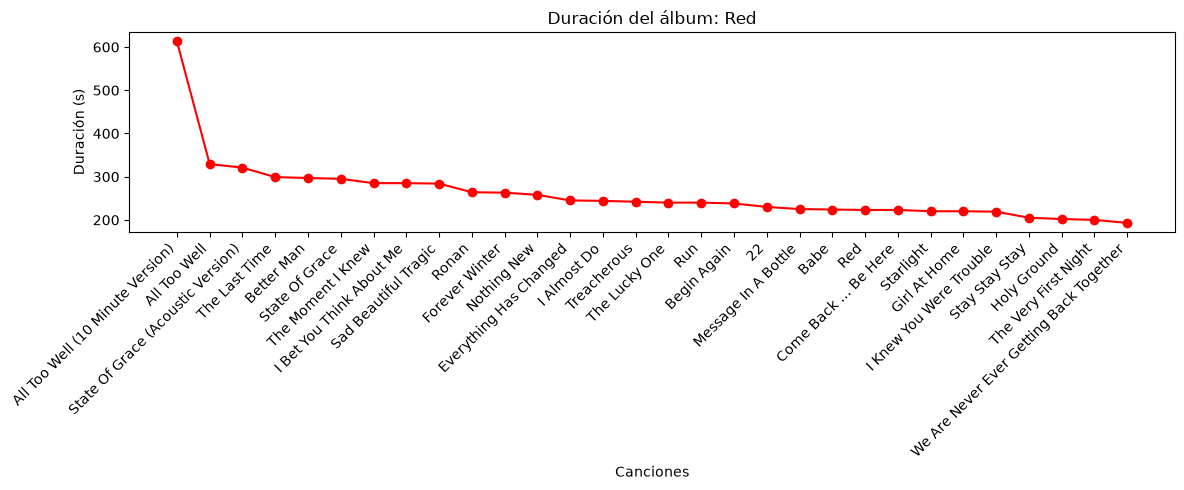

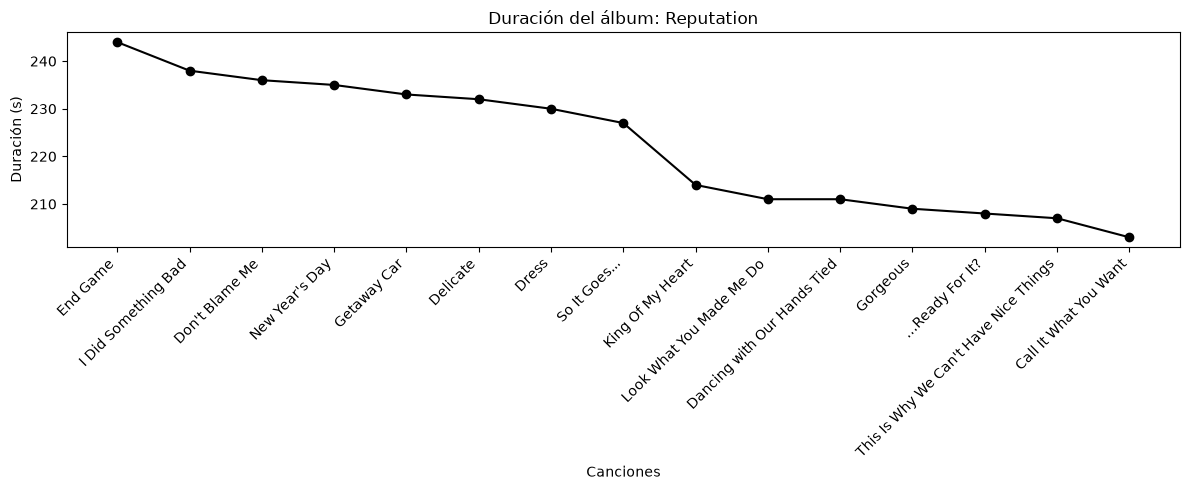

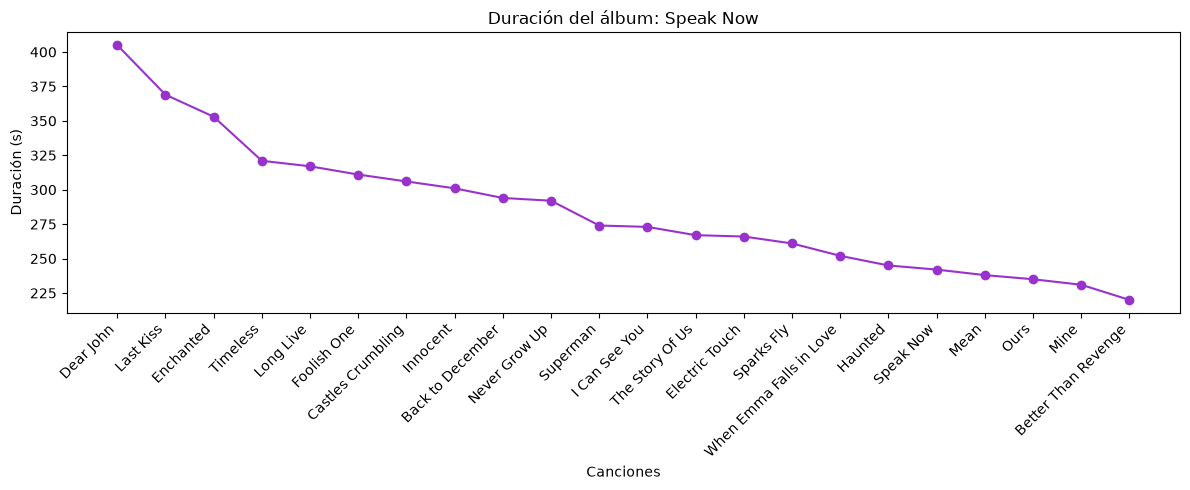

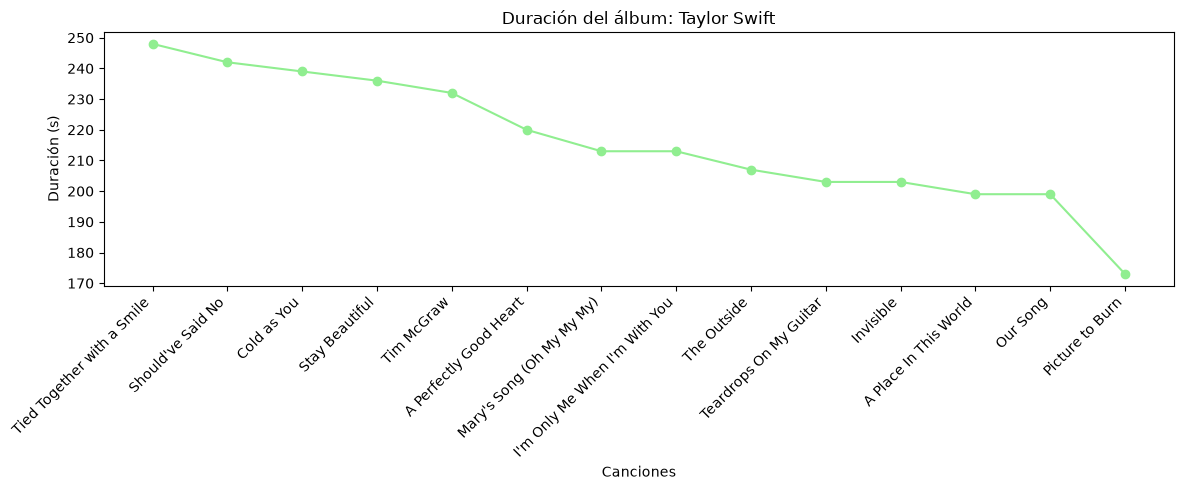

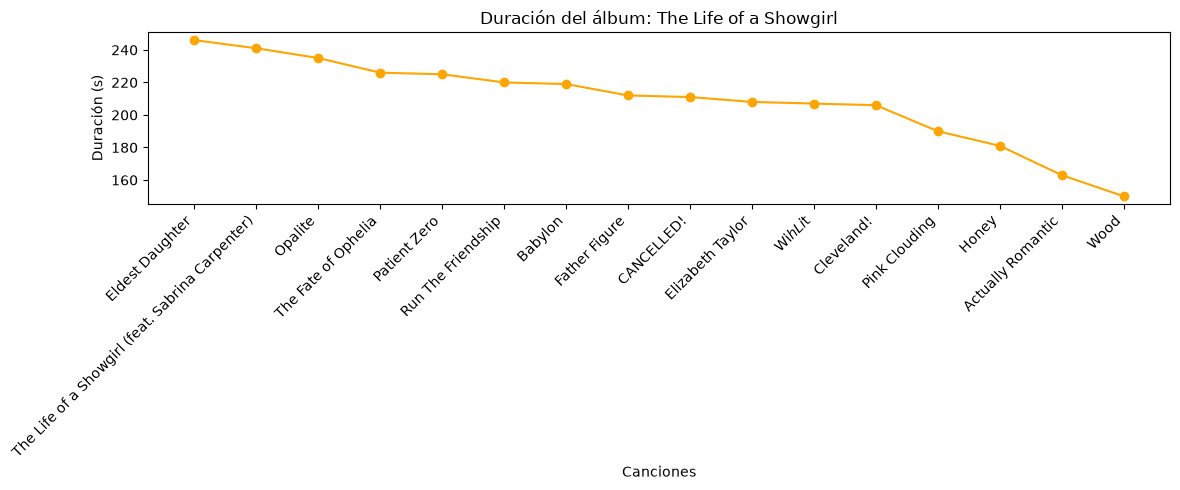

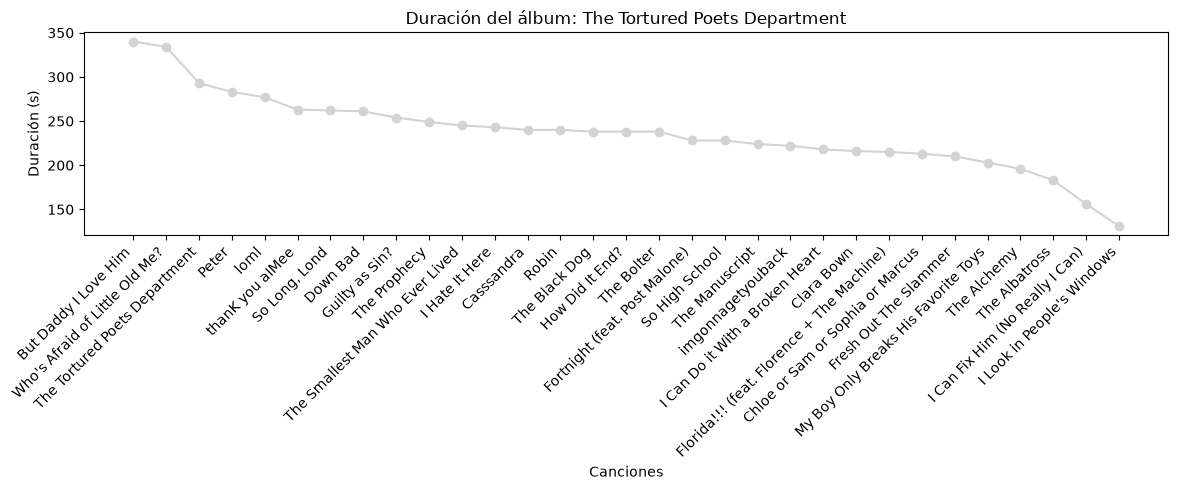

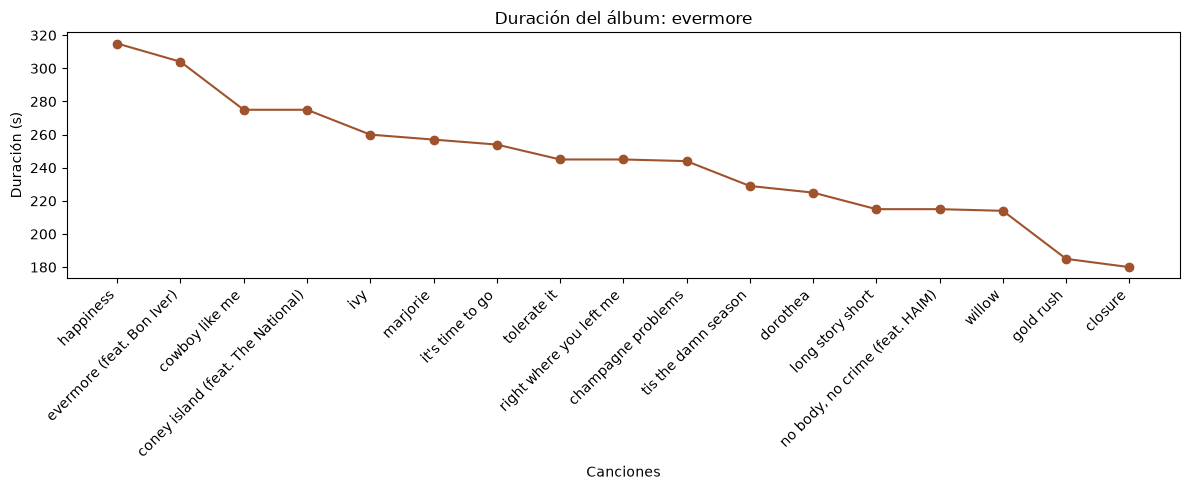

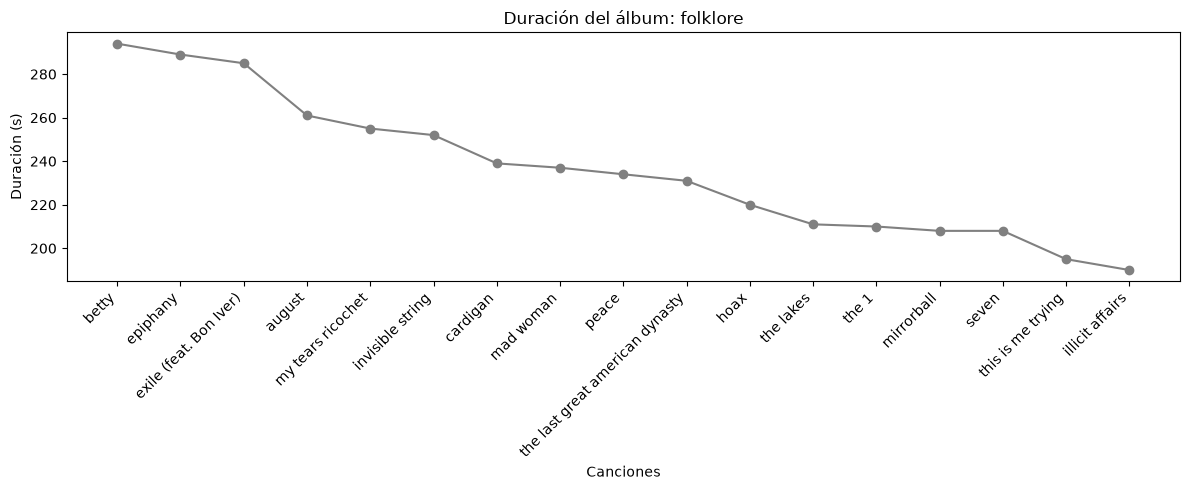

In [13]:
sorted_column = data.sort_values(
    ['Album', 'Duration (s)'],
    ascending=[True, False]
)

album_colors = {
    'Taylor Swift': 'lightgreen',
    'Fearless': 'gold',
    'Speak Now': 'darkorchid',
    'Red': 'red',
    '1989': 'lightskyblue',
    'Reputation': 'black',
    'Lover': 'hotpink',
    'folklore': 'grey',
    'evermore': 'sienna',
    'Midnights': 'blue',
    'The Tortured Poets Department': 'lightgrey',
    'The Life of a Showgirl': 'orange'
}

for album, album_data in sorted_column.groupby('Album'):
    plt.figure(figsize=(12, 5))
    plt.plot(album_data['Song Name'],album_data['Duration (s)'],marker='o',color=album_colors[album])
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Canciones")
    plt.ylabel("Duración (s)")
    plt.title(f"Duración del álbum: {album}")
    plt.tight_layout()
    plt.show()

## Análisis de Palabras

Vamos a partir con un analisis de cantidad de palabras en total, vamos a excluir los signos de puntuación.

In [14]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [30]:
data = pd.read_excel("Taylor_Swift_Genius_Data.xlsx",header=0)
data['Album'] = data['Album'].astype(str)
data['Song Name'] = data['Song Name'].astype(str)

data.head()
len(data)

251

In [36]:
indices_to_drop = data[data['Lyrics'] == "-"].index
print(indices_to_drop)
data.drop(indices_to_drop, inplace=True)
len(data)

Index([29, 81, 113, 202, 203], dtype='int64')


246

In [31]:
def palabras_unicas(texto):
    palabras = re.findall(r'\b[a-zA-ZÀ-ÿ]+\b', str(texto).lower())
    return set(palabras)

def palabras_totales(texto):
    palabras = re.findall(r'\b[a-zA-ZÀ-ÿ]+\b', str(texto).lower())
    return palabras

In [32]:
data["Número unico de palabras"] = data["Lyrics"].apply(lambda x: len(palabras_unicas(x)))
data["Palabras Totales"] = data["Lyrics"].apply(lambda x: len(palabras_totales(x)))

In [37]:
words_max = data["Palabras Totales"].idxmax()
words_min = data["Palabras Totales"].idxmin()

print("Mayor número de palabras:", data.loc[words_max, "Palabras Totales"])
print("Canción:", data.loc[words_max, "Song Name"])

print("Menor número de palabras:", data.loc[words_min, "Palabras Totales"])
print("Canción:", data.loc[words_min, "Song Name"])

Mayor número de palabras: 994
Canción: All Too Well (10 Minute Version)
Menor número de palabras: 167
Canción: It's Nice to Have a Friend


In [38]:
words_max = data["Número unico de palabras"].idxmax()
words_min = data["Número unico de palabras"].idxmin()

print("Mayor número de palabras:", data.loc[words_max, "Número unico de palabras"])
print("Canción:", data.loc[words_max, "Song Name"])

print("Menor número de palabras:", data.loc[words_min, "Número unico de palabras"])
print("Canción:", data.loc[words_min, "Song Name"])

Mayor número de palabras: 329
Canción: All Too Well (10 Minute Version)
Menor número de palabras: 75
Canción: A Perfectly Good Heart


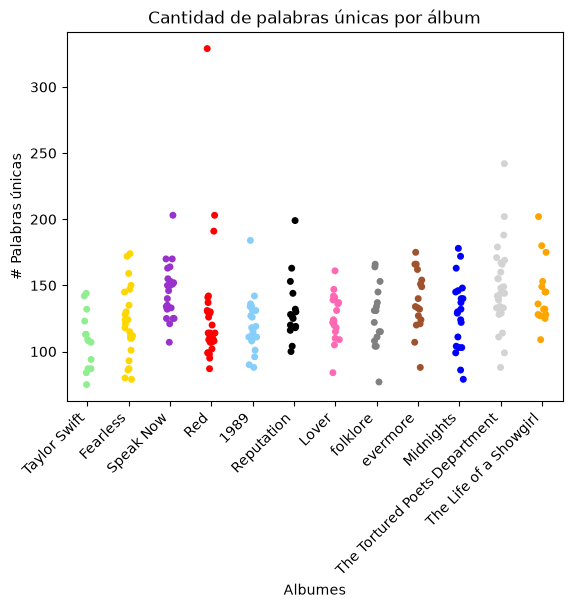

In [39]:
sns.stripplot(data=data,x='Album',y='Número unico de palabras',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("# Palabras únicas")
plt.xlabel("Albumes")
plt.title("Cantidad de palabras únicas por álbum")
plt.show()

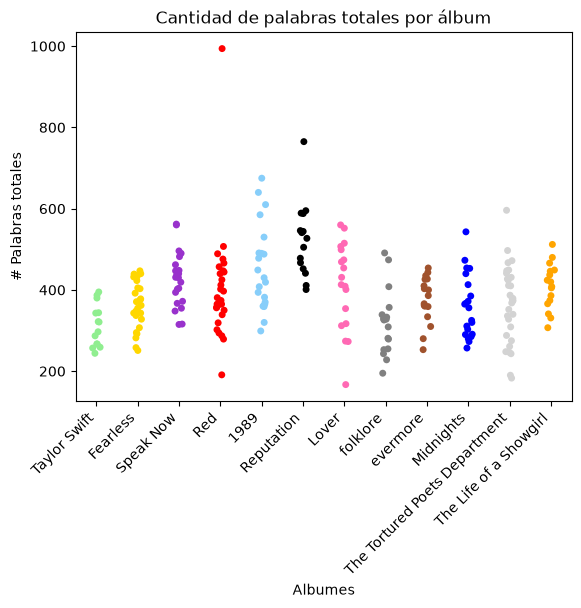

In [40]:
sns.stripplot(data=data,x='Album',y='Palabras Totales',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("# Palabras totales")
plt.xlabel("Albumes")
plt.title("Cantidad de palabras totales por álbum")
plt.show()

In [41]:
unique_words_album = data.groupby("Album")["Lyrics"].apply(lambda x: len(set(palabra for letra in x for palabra in re.findall(r'\b[a-zA-ZÀ-ÿ]+\b', str(letra).lower()))))
print("Cantidad de palabras únicas por álbum:")
print(unique_words_album)

Cantidad de palabras únicas por álbum:
Album
1989                             1028
Fearless                          976
Lover                             999
Midnights                        1212
Red                              1211
Reputation                        908
Speak Now                        1182
Taylor Swift                      639
The Life of a Showgirl           1127
The Tortured Poets Department    1876
evermore                         1099
folklore                         1048
Name: Lyrics, dtype: int64


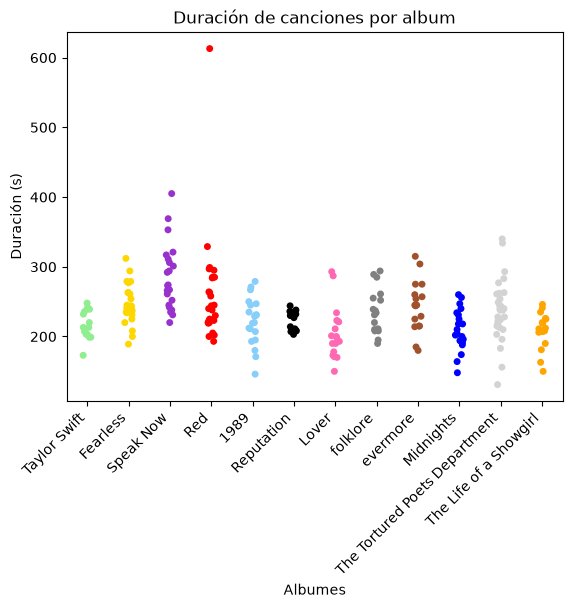

In [42]:
sns.stripplot(data=data,x='Album',y='Duration (s)',hue='Album',palette={'Taylor Swift':'lightgreen','Fearless':'gold','Speak Now':'darkorchid','Red':'red','1989': 'lightskyblue','Reputation':'black','Lover':'hotpink','folklore':'grey','evermore':'sienna','Midnights':'Blue','The Tortured Poets Department':'lightgrey','The Life of a Showgirl':'orange'})#.tick_params(axis="x", rotation=45)
plt.xticks(rotation=45,fontsize=10,ha='right')
#plt.tight_layout()
plt.ylabel("Duración (s)")
plt.xlabel("Albumes")
plt.title("Duración de canciones por album")
plt.show()

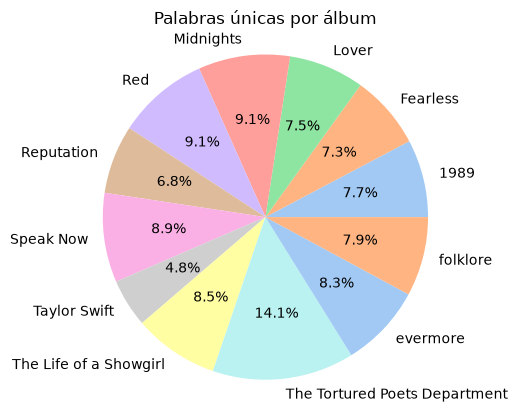

In [43]:
plt.pie(unique_words_album,labels=unique_words_album.index,colors=sns.color_palette('pastel'),autopct='%1.1f%%',radius=1.1)
plt.title("Palabras únicas por álbum")
plt.show()

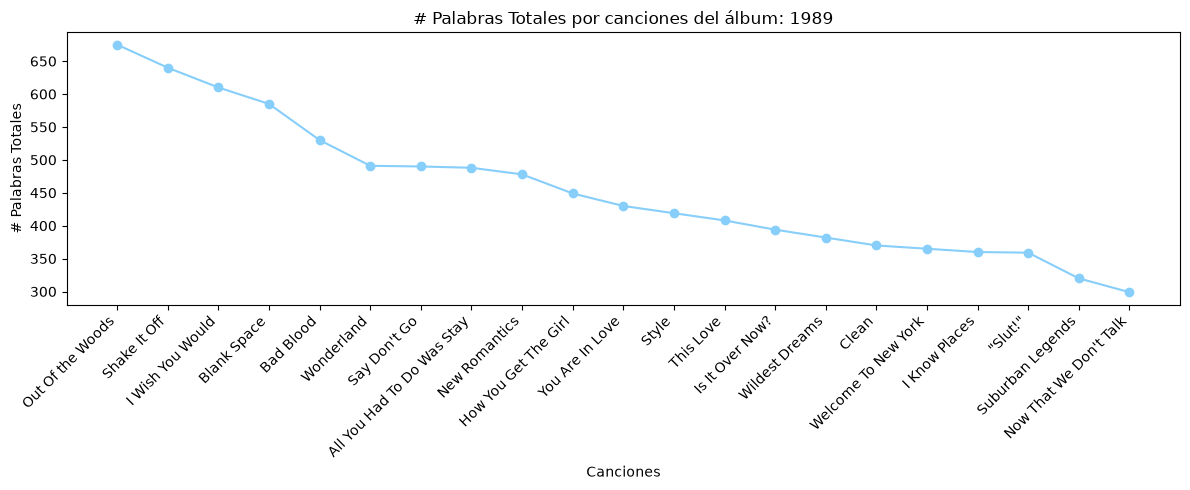

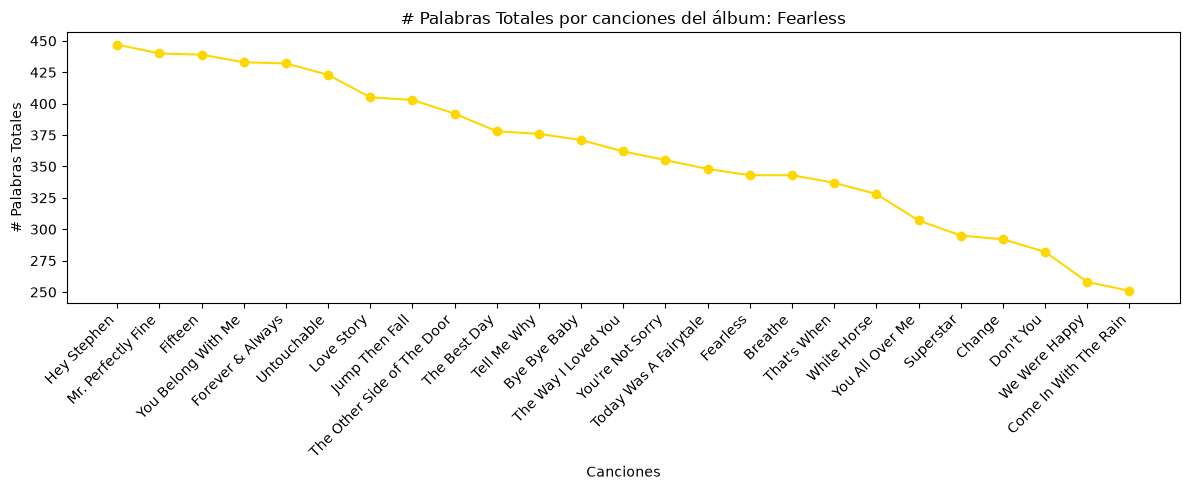

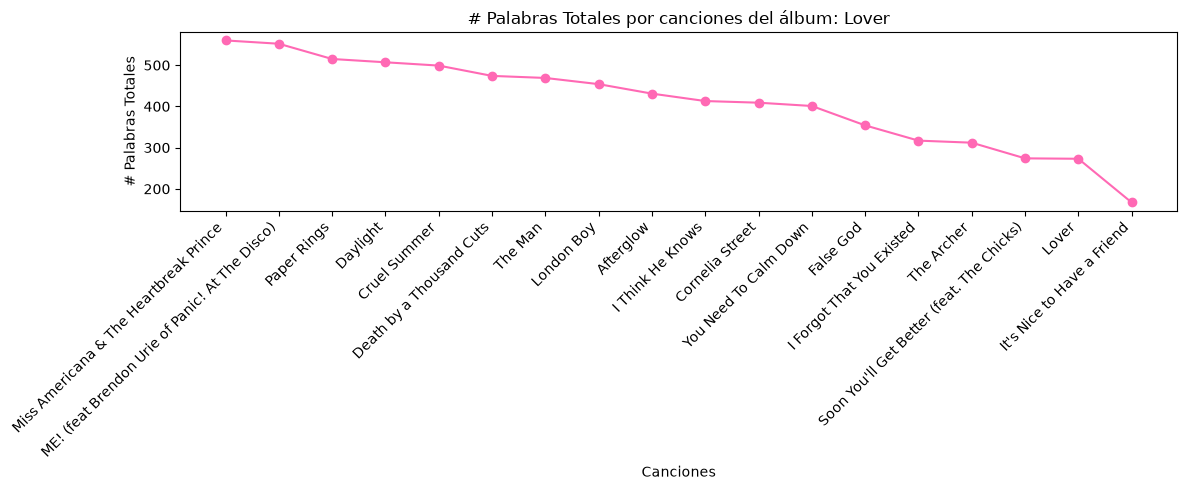

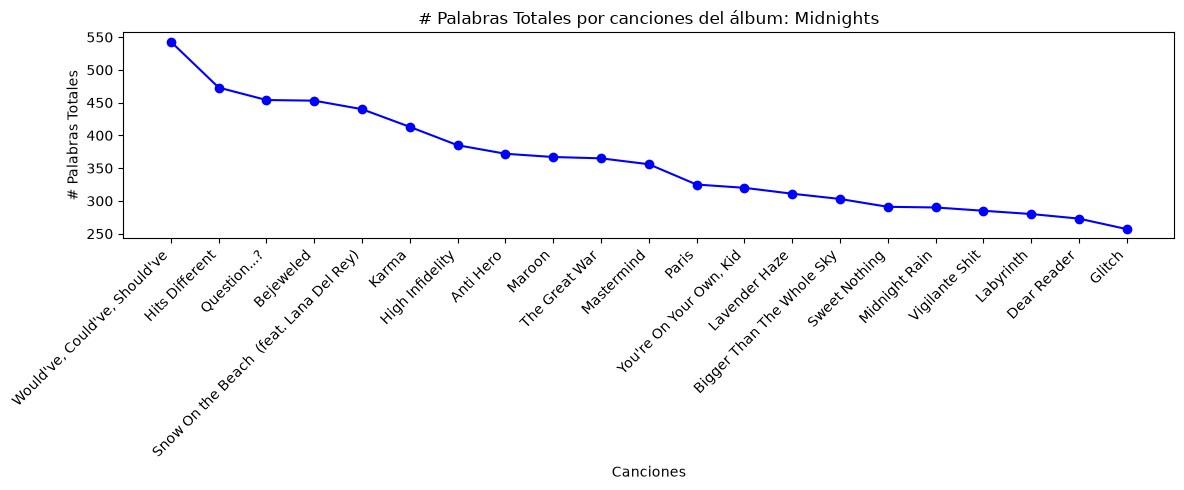

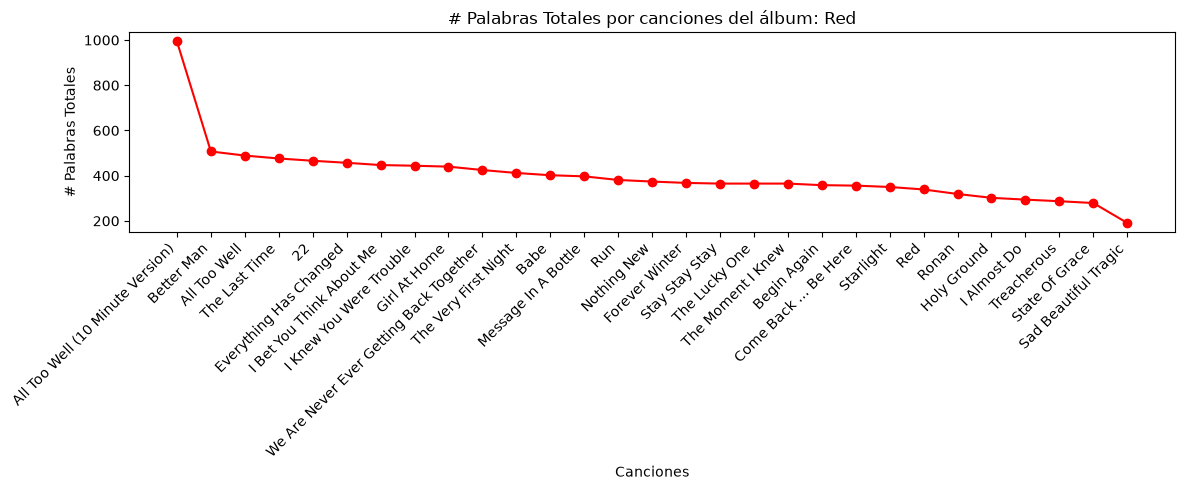

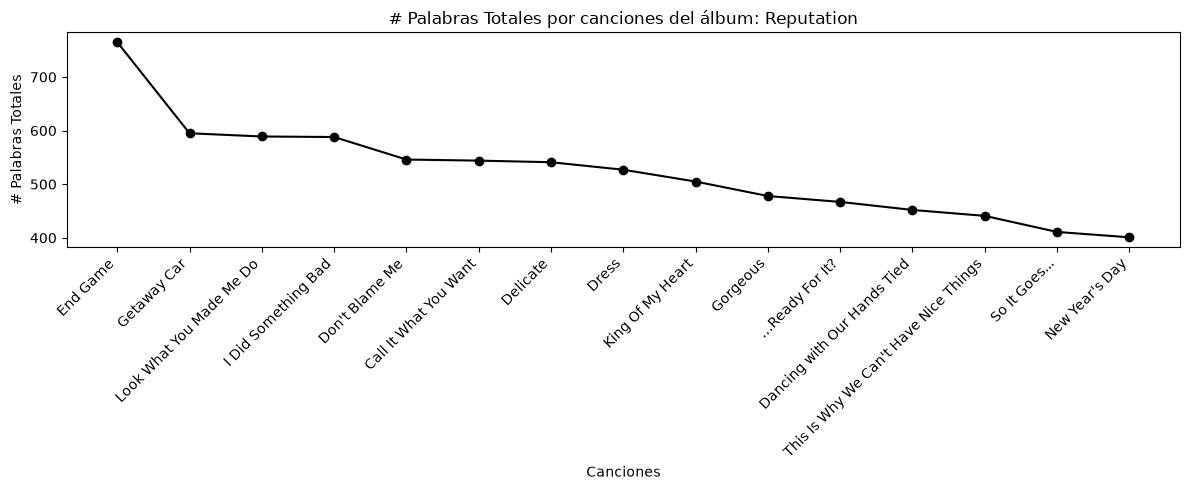

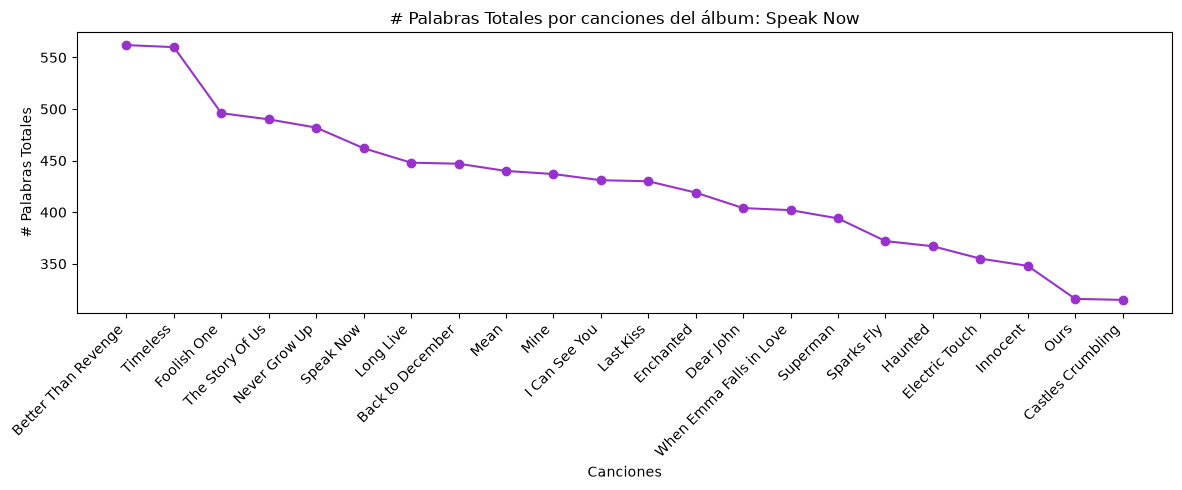

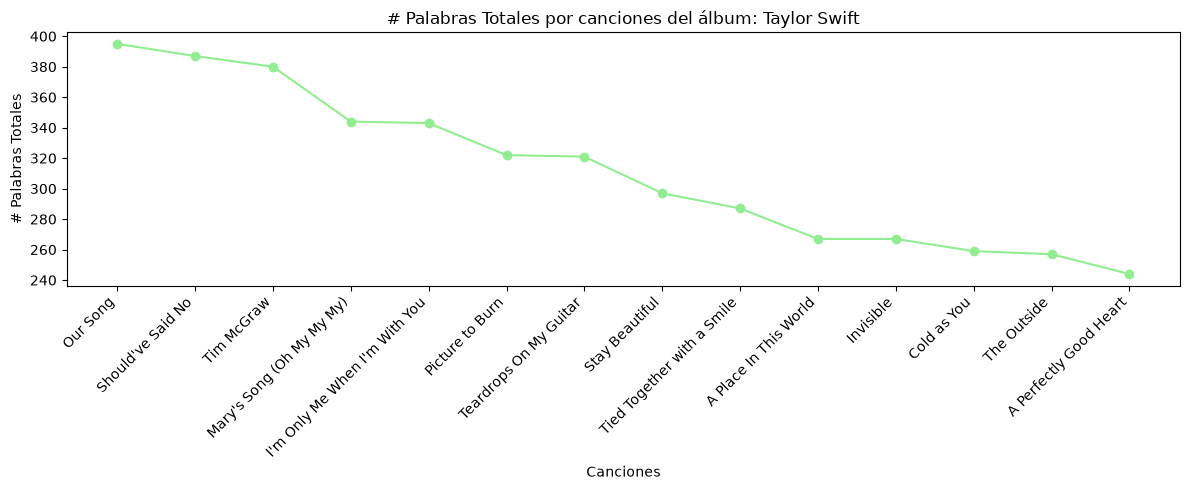

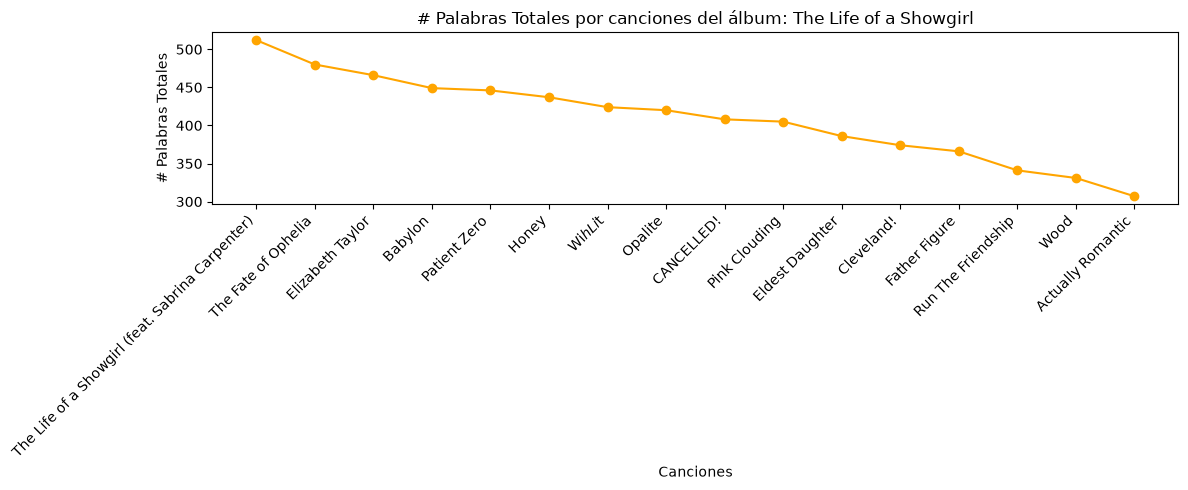

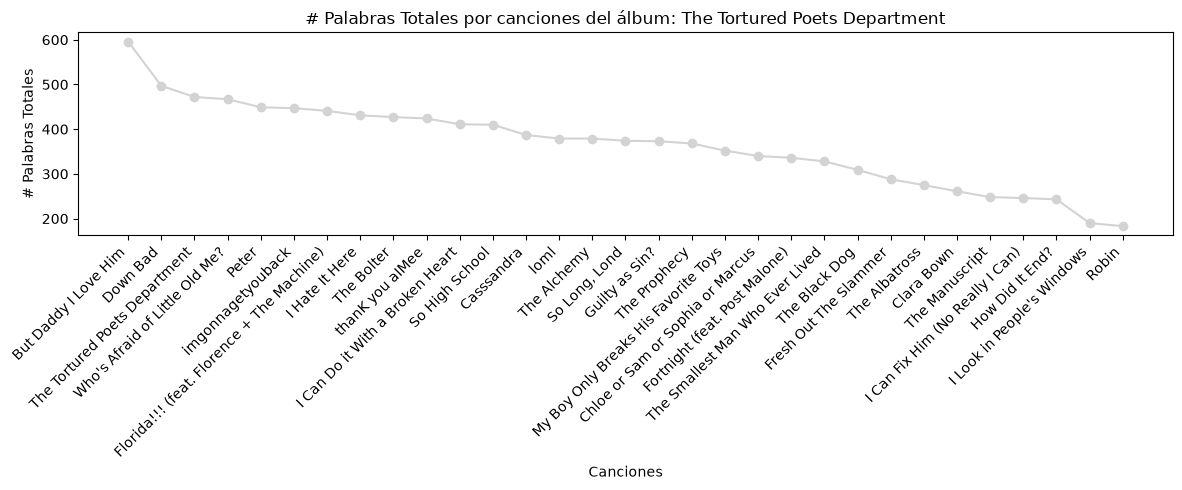

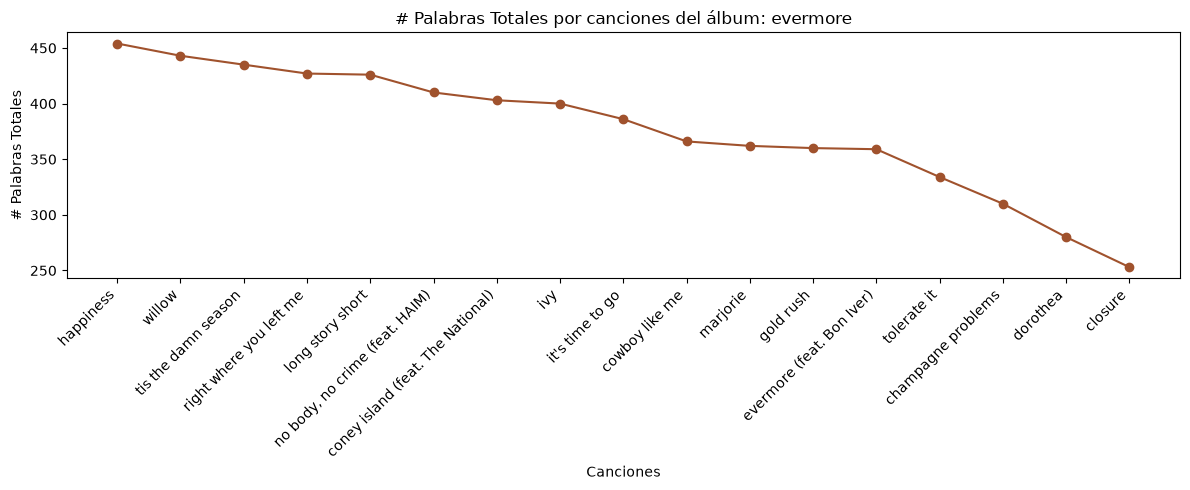

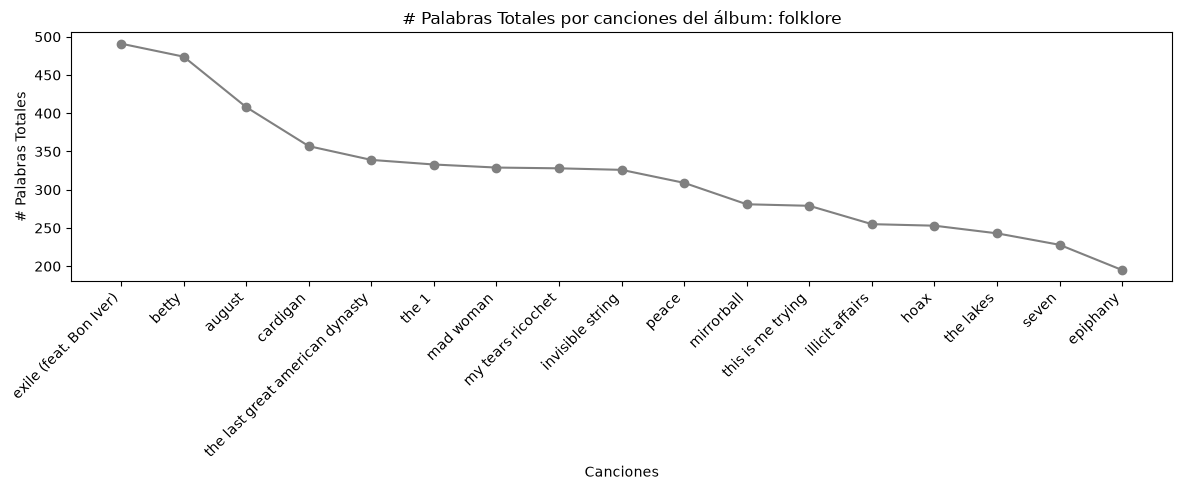

In [44]:
sorted_column = data.sort_values(['Album', 'Palabras Totales'],ascending=[True, False])
album_colors = {'Taylor Swift': 'lightgreen','Fearless': 'gold','Speak Now': 'darkorchid','Red': 'red','1989': 'lightskyblue','Reputation': 'black','Lover': 'hotpink','folklore': 'grey','evermore': 'sienna','Midnights': 'blue','The Tortured Poets Department': 'lightgrey','The Life of a Showgirl': 'orange'}

for album, album_data in sorted_column.groupby('Album'):
    plt.figure(figsize=(12, 5))
    plt.plot(album_data['Song Name'],album_data['Palabras Totales'],marker='o',color=album_colors[album])
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Canciones")
    plt.ylabel("# Palabras Totales")
    plt.title(f"# Palabras Totales por canciones del álbum: {album}")
    plt.tight_layout()
    plt.show()